# Week 18: Advanced ML Analytics (LSTM Anomaly Prediction)

This notebook implements a simple LSTM model for anomaly prediction from sleep/activity patterns and includes core evaluation metrics and visualizations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef, log_loss,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)

In [2]:
# Generate synthetic sleep/activity time-series with injected anomalies
n_samples = 1800
hours = pd.date_range("2026-01-01", periods=n_samples, freq="h")
t = np.arange(n_samples)

sleep_hours = 7.0 + 1.2 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 0.35, n_samples)
activity_level = 5000 + 1800 * np.sin(2 * np.pi * (t + 8) / 24) + np.random.normal(0, 650, n_samples)
heart_rate = 67 + 8 * np.sin(2 * np.pi * (t + 2) / 24) + np.random.normal(0, 3, n_samples)
stress_score = 42 + 9 * np.cos(2 * np.pi * t / 24) + np.random.normal(0, 4, n_samples)

sleep_hours = np.clip(sleep_hours, 3.5, 10)
activity_level = np.clip(activity_level, 300, 14000)
heart_rate = np.clip(heart_rate, 45, 120)
stress_score = np.clip(stress_score, 10, 95)

anomaly = np.zeros(n_samples, dtype=int)
event_indices = np.random.choice(np.arange(48, n_samples - 48), size=80, replace=False)

for idx in event_indices:
    anomaly[idx] = 1
    sleep_hours[idx] = np.clip(sleep_hours[idx] - np.random.uniform(2.0, 3.5), 2.0, 10)
    activity_level[idx] = np.clip(activity_level[idx] + np.random.uniform(3500, 6000), 300, 16000)
    heart_rate[idx] = np.clip(heart_rate[idx] + np.random.uniform(15, 30), 45, 145)
    stress_score[idx] = np.clip(stress_score[idx] + np.random.uniform(18, 35), 10, 100)

df = pd.DataFrame({
    "timestamp": hours,
    "sleep_hours": sleep_hours,
    "activity_level": activity_level,
    "heart_rate": heart_rate,
    "stress_score": stress_score,
    "anomaly": anomaly
})

df.head()

,timestamp,sleep_hours,activity_level,heart_rate,stress_score,anomaly
0,2026-01-01 00:00:00,7.173850,7794.619673,68.528194,46.248939,0
1,2026-01-01 01:00:00,7.262190,6233.362677,70.499526,49.104039,0
2,2026-01-01 02:00:00,7.826691,5439.535602,80.077640,51.931688,0
3,2026-01-01 03:00:00,8.381589,4481.959926,74.729455,48.728335,0
4,2026-01-01 04:00:00,7.957277,3827.959210,77.346390,43.093840,0


In [3]:
# Prepare train/test data and convert to LSTM sequences
feature_cols = ["sleep_hours", "activity_level", "heart_rate", "stress_score"]
X = df[feature_cols].to_numpy(dtype=float)
y = df["anomaly"].to_numpy(dtype=int)

lookback = 24
test_ratio = 0.2
split_idx = int(len(X) * (1 - test_ratio))

X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
y_train_raw, y_test_raw = y[:split_idx], y[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

def create_sequences(features, labels, lookback_window):
    X_seq, y_seq = [], []
    for i in range(lookback_window, len(features)):
        X_seq.append(features[i - lookback_window:i])
        y_seq.append(labels[i])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_raw, lookback)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_raw, lookback)

X_train_seq.shape, X_test_seq.shape

((1416, 24, 4), (336, 24, 4))

In [4]:
# Build and train a simple LSTM classifier
model = Sequential([
    LSTM(32, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25


e:\Sharvayu data\Malware\Symbiosis Nagpur SIT\6th SEM\Hack-O-Week\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8313 - loss: 0.5424 - val_accuracy: 0.9472 - val_loss: 0.3136
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9549 - loss: 0.2123 - val_accuracy: 0.9472 - val_loss: 0.2136
Epoch 3/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9549 - loss: 0.1888 - val_accuracy: 0.9472 - val_loss: 0.2101
Epoch 4/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9549 - loss: 0.1887 - val_accuracy: 0.9472 - val_loss: 0.2102
Epoch 5/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9549 - loss: 0.1882 - val_accuracy: 0.9472 - val_loss: 0.2114
Epoch 6/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9549 - loss: 0.1847 - val_accuracy: 0.9472 - val_loss: 0.2102
Epoch 7/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9549 - loss: 0.1845 - val_accuracy: 0.9472 - val_loss: 0.2103
Epoch 8/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9549 - loss: 0.1822 - val_accuracy: 0.9472 - val_loss: 0.2099
Ep

In [5]:
# Predict and compute evaluation metrics
threshold = 0.5
y_prob = model.predict(X_test_seq, verbose=0).reshape(-1)
y_pred = (y_prob >= threshold).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test_seq, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test_seq, y_pred),
    "precision": precision_score(y_test_seq, y_pred, zero_division=0),
    "recall": recall_score(y_test_seq, y_pred, zero_division=0),
    "f1_score": f1_score(y_test_seq, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test_seq, y_prob),
    "pr_auc": average_precision_score(y_test_seq, y_prob),
    "mcc": matthews_corrcoef(y_test_seq, y_pred),
    "log_loss": log_loss(y_test_seq, y_prob, labels=[0, 1])
}

metrics_df = pd.DataFrame([metrics]).T.reset_index()
metrics_df.columns = ["metric", "value"]
metrics_df

,metric,value
0,accuracy,0.964286
1,balanced_accuracy,0.500000
2,precision,0.000000
3,recall,0.000000
4,f1_score,0.000000
5,roc_auc,0.324331
6,pr_auc,0.052795
7,mcc,0.000000
8,log_loss,0.162142


In [6]:
print("Classification Report:\n")
print(classification_report(y_test_seq, y_pred, digits=4, zero_division=0))

Classification Report:

              precision    recall  f1-score   support

           0     0.9643    1.0000    0.9818       324
           1     0.0000    0.0000    0.0000        12

    accuracy                         0.9643       336
   macro avg     0.4821    0.5000    0.4909       336
weighted avg     0.9298    0.9643    0.9468       336



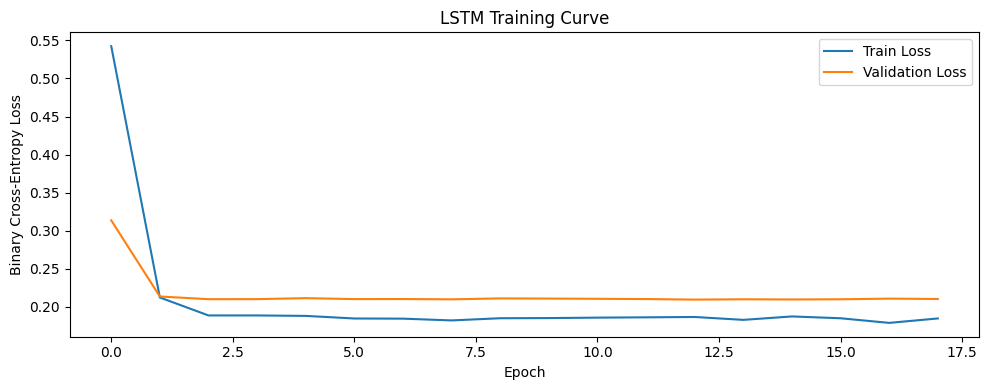

In [7]:
# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.tight_layout()
plt.show()

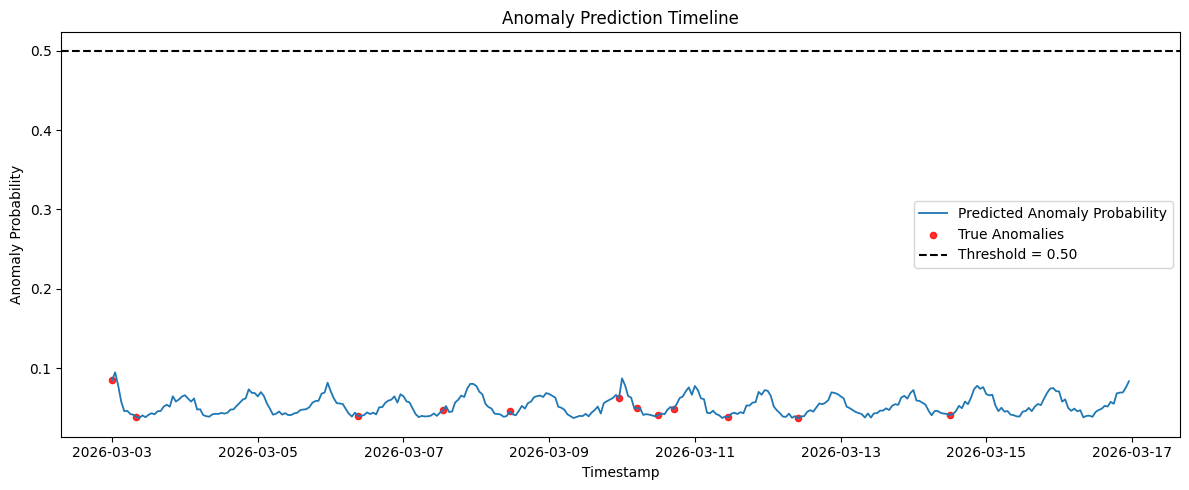

In [8]:
# Plot anomaly probabilities over time
timestamps_test = df["timestamp"].to_numpy()[split_idx + lookback:]

plt.figure(figsize=(12, 5))
plt.plot(timestamps_test, y_prob, label="Predicted Anomaly Probability", linewidth=1.3)
plt.scatter(
    timestamps_test[y_test_seq == 1],
    y_prob[y_test_seq == 1],
    color="red",
    s=20,
    alpha=0.8,
    label="True Anomalies"
)
plt.axhline(y=threshold, color="black", linestyle="--", label=f"Threshold = {threshold:.2f}")
plt.title("Anomaly Prediction Timeline")
plt.xlabel("Timestamp")
plt.ylabel("Anomaly Probability")
plt.legend()
plt.tight_layout()
plt.show()

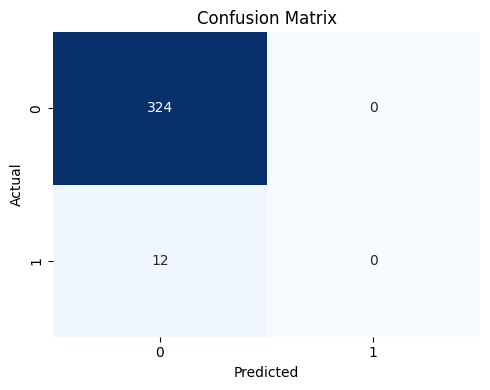

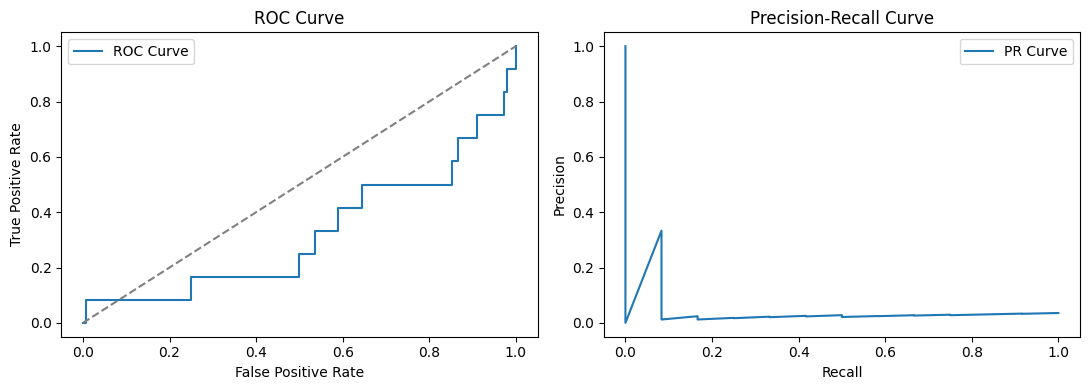

In [9]:
# Confusion matrix, ROC curve, and Precision-Recall curve
cm = confusion_matrix(y_test_seq, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test_seq, y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_test_seq, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, label="ROC Curve")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, label="PR Curve")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()